# Group Splitting Training (Unified Config Pipeline)

This notebook shows how to train/evaluate/export the group-splitting model with the unified `training_pipeline`.


## 1) Environment Setup


In [1]:
from pathlib import Path

from pioneerml.evaluation.plots.loss import LossCurvesPlot
from pioneerml.integration.zenml import load_step_output
from pioneerml.integration.zenml import utils as zenml_utils
from pioneerml.pipeline.pipelines.training import training_pipeline

PROJECT_ROOT = zenml_utils.find_project_root()
zenml_utils.setup_zenml_for_notebook(root_path=PROJECT_ROOT, use_in_memory=True)


Using ZenML repository root: /workspace
Ensure this is the top-level of your repo (.zen must live here).


## 2) Build Aligned Main + Group-Probability Inputs

Group-splitting requires the original event parquet plus aligned group-classifier probability parquet for each shard.


In [2]:
# Build aligned parquet/probability inputs.
# Expected prediction shard naming: ml_output_XXX_preds.parquet

data_dir = Path(PROJECT_ROOT) / "data"
main_paths = sorted(data_dir.glob("ml_output_*.parquet"))
probs_dir = data_dir / "group_classifier"

# Example: uncomment to select a smaller subset
main_paths = main_paths[:1]


def _pick_group_classifier_preds(main_path: Path) -> Path | None:
    candidates = [
        probs_dir / f"{main_path.stem}_preds.parquet",
        probs_dir / f"{main_path.stem}_preds_latest.parquet",
    ]
    for c in candidates:
        if c.exists():
            return c
    return None


paired = []
missing_prob_paths = []
for main_path in main_paths:
    pred_path = _pick_group_classifier_preds(main_path)
    if pred_path is not None:
        paired.append((str(main_path.resolve()), str(pred_path.resolve())))
    else:
        missing_prob_paths.append(str((probs_dir / f"{main_path.stem}_preds.parquet").resolve()))

if not paired:
    raise RuntimeError(
        "No aligned parquet/prediction pairs found. "
        "Run group-classifier inference first to generate *_preds.parquet files."
    )
if missing_prob_paths:
    print(f"Warning: missing {len(missing_prob_paths)} prediction shard(s); skipping those files.")

parquet_paths = [p for p, _ in paired]
group_probs_parquet_paths = [p for _, p in paired]
print(f"Using {len(parquet_paths)} shard(s) for group-splitter training.")


Using 1 shard(s) for group-splitter training.


## 3) Reusable Config Helpers


In [3]:
from pioneerml.plugin.runtime import ensure_plugins_loaded
ensure_plugins_loaded()

from pioneerml_base_plugin.group_splitter.pipeline import load_config
from pioneerml_base_plugin.utils.config_loader import with_export_output, with_loader_sources


## 4) Build Step Config Blocks

HPO search-space keys are routed automatically:
- architecture keys (`hidden`, `heads`, `layers`, `dropout`) -> `architecture.config`
- module keys (`lr`, `weight_decay`) -> `module.config`
- runtime keys (`batch_size`) -> loader defaults.


In [4]:
pipeline_config = load_config()["training"]
pipeline_config = with_loader_sources(
    pipeline_config,
    main_sources=parquet_paths,
    optional_sources_by_name={"group_probs": group_probs_parquet_paths},
)
pipeline_config = with_export_output(
    pipeline_config,
    export_dir=str(Path(PROJECT_ROOT) / "trained_models" / "groupsplitter"),
    filename_prefix="groupsplitter",
)


## 5) Assemble `pipeline_config` and Run


In [5]:
run = training_pipeline.with_options(enable_cache=False)(
    pipeline_config=pipeline_config,
)


Initiating a new run for the pipeline: training_pipeline.
Caching is disabled by default for training_pipeline.
Using user: default
Using stack: default
  deployer: default
  artifact_store: default
  orchestrator: default
You can visualize your pipeline runs in the ZenML Dashboard. In order to try it locally, please run zenml login --local.
Step tune_model has started.


[I 2026-03-26 01:28:13,893] A new study created in RDB with name: group_splitter_hpo


[tune_model] GPU available: True (cuda), used: True
[tune_model] TPU available: False, using: 0 TPU cores
[tune_model] You are using a CUDA device ('NVIDIA GeForce RTX 5070') that has Tensor Cores. To properly utilize them, you should set torch.set_float32_matmul_precision('medium' | 'high') which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
[tune_model] LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ GroupSplitter     │  842 K │ train │     0 │
│ 1 │ loss_fn │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 842 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 842 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 54                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Step tune_model has finished in 17.285s.
Step train_model has started.
[train_model] GPU available: True (cuda), used: True
[train_model] TPU available: False, using: 0 TPU cores
[train_model] LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ GroupSplitter     │  2.1 M │ train │     0 │
│ 1 │ loss_fn │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 2.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.1 M                                                                                                
Total estimated model params size (MB): 8                                                                          
Modules in train mode: 54                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

[train_model] No materializer is registered for type <class 'pioneerml.integration.pytorch.modules.graph_lightning_module.GraphLightningModule'>, so the default Pickle materializer was used. Pickle is not production ready and should only be used for prototyping as the artifacts cannot be loaded when running with a different Python version. Please consider implementing a custom materializer for type <class 'pioneerml.integration.pytorch.modules.graph_lightning_module.GraphLightningModule'> according to the instructions at https://docs.zenml.io/concepts/artifacts/materializers
Step train_model has finished in 19.447s.
Step evaluate_model has started.
Step evaluate_model has finished in 2.521s.
Step export_model has started.
Step export_model has finished in 0.927s.
Pipeline run has finished in 43.084s.


## 6) Load Step Outputs and Inspect Results


hpo_params: {'study_name': 'group_splitter_hpo', 'storage': 'sqlite:////workspace/.optuna/group_splitter_hpo.db', 'best_params': {'batch_size_exp': 6, 'lr': 0.000413226476640552, 'weight_decay': 2.531401702066131e-06, 'hidden': 240, 'heads': 8, 'layers': 3, 'dropout': 0.07382324447697487, 'batch_size': 64}}
metrics (summary): {'loss': 0.059592698758811326, 'accuracy': 0.986451763606634, 'exact_match': 0.9705676243868255, 'confusion': [{'tn': 0.5014716187806587, 'fp': 0.004905395935529082, 'fn': 0.007147862648913805, 'tp': 0.4864751226348984}, {'tn': 0.8689558514365803, 'fp': 0.010371408549404345, 'fn': 0.006026629292221444, 'tp': 0.11464611072179397}, {'tn': 0.61541695865452, 'fp': 0.012193412754029432, 'fn': 0.0, 'tp': 0.3723896285914506}], 'threshold': 0.5, 'train_loss_history_total_points': 9, 'val_loss_history_total_points': 10}
export: {'torchscript_path': '/workspace/trained_models/groupsplitter/groupsplitter_20260326_012855_torchscript.pt', 'metadata_path': '/workspace/trained_m

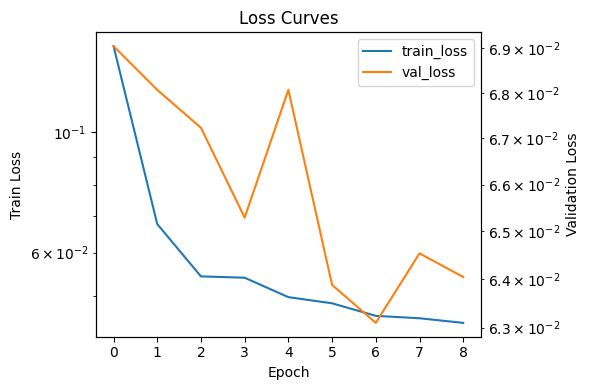

In [6]:
hpo_output = load_step_output(run, "tune_model")
train_output = load_step_output(run, "train_model")
evaluate_output = load_step_output(run, "evaluate_model")
export_output = load_step_output(run, "export_model")

hpo_params = hpo_output.get("hpo_params") if isinstance(hpo_output, dict) else hpo_output
trained_module = train_output.get("module") if isinstance(train_output, dict) else train_output
metrics = evaluate_output.get("metrics") if isinstance(evaluate_output, dict) else evaluate_output

summary = dict(metrics or {})
summary.pop("train_loss_history", None)
summary.pop("val_loss_history", None)

print("hpo_params:", hpo_params)
print("metrics (summary):", summary)
print("export:", export_output)

if trained_module is None:
    raise RuntimeError("No trained module loaded from pipeline run.")

LossCurvesPlot().render(
    trained_module,
    val_accuracy=(metrics.get("accuracy") if isinstance(metrics, dict) else None),
    show=True,
)
